Классификация изображений с использованием Transfer Learning

**Вариант:** 1 (Классификация изображений)  
**Датасет:** Oxford Flowers 102  
**Архитектура:** ResNet18  


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Предобработка данных

Перед подачей изображений в нейронную сеть выполняются следующие преобразования:

- изменение размера изображений до 224×224
- случайное отражение (data augmentation)
- нормализация (по статистике ImageNet)

Это необходимо, так как:
- модель ResNet обучалась на изображениях размера 224×224
- нормализация ускоряет обучение

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset = torchvision.datasets.Flowers102(
    root="./data",
    split="train",
    download=True,
    transform=transform
)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

100%|██████████| 345M/345M [00:16<00:00, 20.8MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.10MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 26.6MB/s]


## Архитектура модели

В работе используется модель ResNet18.

ResNet — это глубокая сверточная нейронная сеть с остаточными связями (skip connections), которые позволяют эффективно обучать глубокие модели.

Особенности:
- предобучена на датасете ImageNet
- используется как extractor признаков
- последний слой заменён под текущую задачу (102 класса)


In [3]:
model = torchvision.models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 102)
)


for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


In [4]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    max_batches=len(loader)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if i >= max_batches:
                break

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

Epoch 1: Loss=0.5195, Train Acc=0.9154, Val Acc=0.7549
Epoch 2: Loss=0.5528, Train Acc=0.9020, Val Acc=0.7843
Epoch 3: Loss=0.4914, Train Acc=0.9203, Val Acc=0.7451
Epoch 4: Loss=0.5375, Train Acc=0.8909, Val Acc=0.7696
Epoch 5: Loss=0.5008, Train Acc=0.9142, Val Acc=0.7206
Epoch 6: Loss=0.4858, Train Acc=0.9265, Val Acc=0.7549
Epoch 7: Loss=0.4876, Train Acc=0.9154, Val Acc=0.7255
Epoch 8: Loss=0.4750, Train Acc=0.9277, Val Acc=0.7843
Epoch 9: Loss=0.4329, Train Acc=0.9350, Val Acc=0.7402
Epoch 10: Loss=0.4605, Train Acc=0.9326, Val Acc=0.7353
Epoch 11: Loss=0.4535, Train Acc=0.9240, Val Acc=0.7696
Epoch 12: Loss=0.4423, Train Acc=0.9130, Val Acc=0.7402
Epoch 13: Loss=0.4592, Train Acc=0.9154, Val Acc=0.7745
Epoch 14: Loss=0.4190, Train Acc=0.9338, Val Acc=0.7549
Epoch 15: Loss=0.4143, Train Acc=0.9289, Val Acc=0.7598


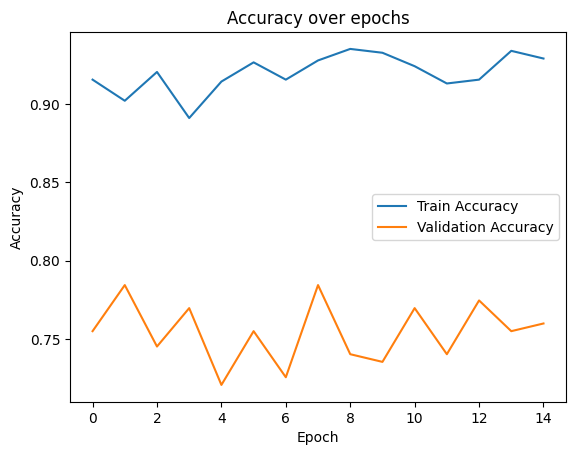

In [11]:
EPOCHS = 15

train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

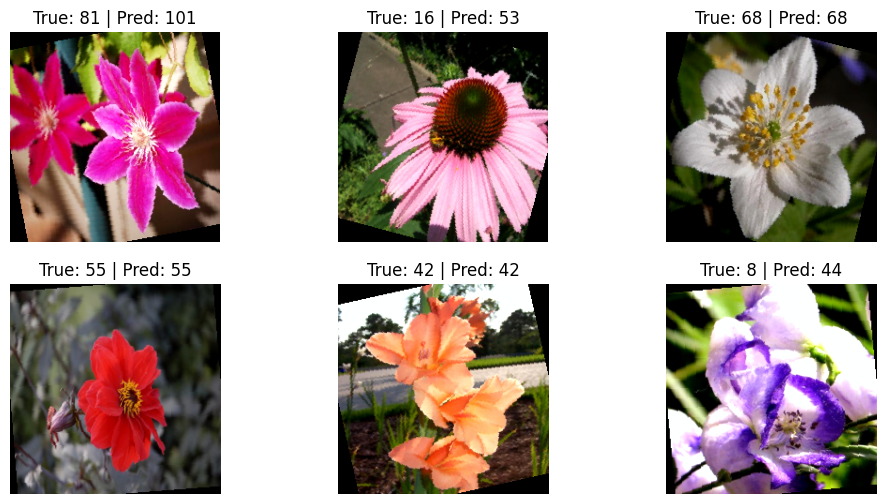

In [9]:
dataiter = iter(val_loader)
images, labels = next(dataiter)

images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)

    img = images[i].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")

plt.show()

                           precision    recall  f1-score   support

            pink primrose       0.00      0.00      0.00         1
hard-leaved pocket orchid       1.00      1.00      1.00         2
         canterbury bells       0.33      1.00      0.50         1
                sweet pea       0.00      0.00      0.00         0
         english marigold       0.00      0.00      0.00         0
               tiger lily       1.00      1.00      1.00         3
              moon orchid       1.00      0.25      0.40         4
         bird of paradise       1.00      1.00      1.00         5
                monkshood       1.00      1.00      1.00         3
            globe thistle       1.00      1.00      1.00         2
               snapdragon       1.00      0.50      0.67         4
              colt's foot       1.00      1.00      1.00         2
              king protea       1.00      0.50      0.67         4
            spear thistle       0.67      1.00      0.80     

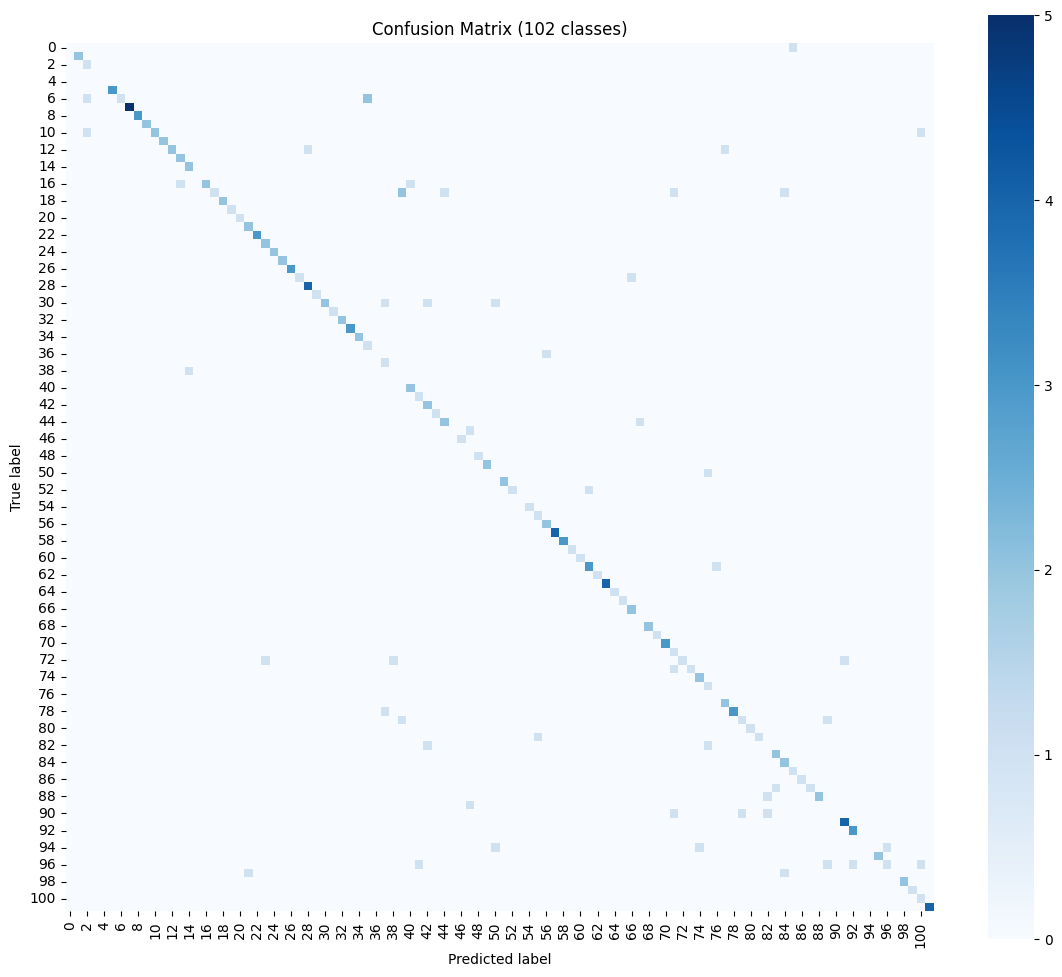

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


all_classes = list(range(102))

print(classification_report(
    all_labels,
    all_preds,
    labels=all_classes,
    target_names=dataset.classes,
    zero_division=0
))


cm = confusion_matrix(all_labels, all_preds, labels=all_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, square=True)
plt.title("Confusion Matrix (102 classes)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()